# 🛡️ Tahap 4 — A/B Testing SafeMessage (Enhanced)
## **Deteksi Phishing Bahasa Indonesia — Analisis Threshold Deployment**

---
**Tim :** CC26-PSU107 | **Tema :** Inclusive & Resilient Communities

---

## 🗺️ Alur Notebook

```
Input
 ├── smishing_model_best.keras   model TextCNN terlatih
 ├── model_config.json           konfigurasi fitur & kolom
 └── dataset_test.csv            hold-out test set

      ↓
 [A] Setup & Load Data
 [B] Simulasi Probabilitas Prediksi
 [C] Threshold Sweep — Justifikasi Threshold Optimal
      └── Visualisasi kurva F1 / Precision / Recall / FNR vs threshold
 [D] Definisi Grup A/B
      ├── Grup A : threshold default  = 0.5
      └── Grup B : threshold optimal  = hasil sweep PR curve
 [E] Hitung Metrik Per Grup
 [F] Uji Statistik Formal
      ├── [F1] McNemar Test (paired classifier comparison)
      ├── [F2] Z-Test Proporsi Akurasi + Wilson 95% CI
      ├── [F3] Effect Size — Cohen's h
      ├── [F4] Wilson CI untuk FNR & FPR
      └── [F5] Power Analysis — berapa N test set yang ideal?
 [G] Visualisasi Komprehensif (8 plot)
 [H] Error Analysis — Pesan Mana yang Salah Prediksi?
 [I] Kesimpulan & Rekomendasi Deployment
      ↓
Output
 └── ab_testing_result.png / ab_error_analysis.csv
```

## 🎯 Hipotesis Penelitian

| | Keterangan |
|---|---|
| **H₀** | Tidak ada perbedaan performa yang signifikan antara threshold 0.5 (default) dan threshold optimal |
| **H₁** | Threshold optimal menghasilkan performa yang secara statistik berbeda dari threshold default |
| **Alpha (α)** | 0.05 |
| **Metrik Primer** | FNR (False Negative Rate) — phishing yang lolos tidak terdeteksi |
| **Metrik Sekunder** | F1-Score, Accuracy, FPR, MAE |

> **Mengapa FNR sebagai metrik primer?**
> Dalam konteks SafeMessage, *false negative* (phishing lolos) lebih berbahaya dari *false positive* (pesan normal dianggap phishing).
> Pengguna yang tidak terdeteksi phishing-nya berpotensi mengalami kerugian finansial nyata.


---
## ⚙️ [A] Setup & Instalasi

In [ ]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn scipy statsmodels -q
print('✅ Instalasi selesai')

✅ Instalasi selesai


In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import binom
from statsmodels.stats.proportion import proportions_ztest, proportion_confint, proportion_effectsize
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, mean_absolute_error,
    roc_curve, precision_recall_curve, auc, average_precision_score
)
import tensorflow as tf

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Warna konsisten ──────────────────────────────────────────────
WARNA_A   = '#3498DB'   # Grup A — threshold default
WARNA_B   = '#E74C3C'   # Grup B — threshold optimal
C_PHISH   = '#E74C3C'
C_NORMAL  = '#2ECC71'

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})

print(f'✅ TensorFlow {tf.__version__}')
print(f'   GPU: {tf.config.list_physical_devices("GPU")}')
print('✅ Semua library siap')

✅ TensorFlow 2.20.0
   GPU: []
✅ Semua library siap


---
## 📦 [B] Load Model & Simulasi Prediksi

In [ ]:
# ── Definisi ulang custom classes (wajib sebelum load model) ────
@tf.keras.utils.register_keras_serializable(package='Custom', name='TextPreprocessingLayer')
class TextPreprocessingLayer(tf.keras.layers.Layer):
    def __init__(self, vocab_size, max_len, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.max_len    = max_len
        self.vectorizer = tf.keras.layers.TextVectorization(
            max_tokens=vocab_size, output_mode='int',
            output_sequence_length=max_len,
            standardize='lower_and_strip_punctuation',
        )
    def build(self, input_shape):
        self.vectorizer.build(input_shape)
        super().build(input_shape)
    def call(self, inputs):
        return self.vectorizer(inputs)
    def get_config(self):
        config = super().get_config()
        config.update({'vocab_size': self.vocab_size, 'max_len': self.max_len})
        return config
    def get_weights(self):
        return self.vectorizer.get_weights()
    def set_weights(self, weights):
        self.vectorizer.set_weights(weights)

@tf.keras.utils.register_keras_serializable(package='Custom', name='WeightedBinaryCrossentropy')
class WeightedBinaryCrossentropy(tf.keras.losses.Loss):
    def __init__(self, weight_0=1.0, weight_1=1.2,
                 label_smoothing=0.0, confidence_penalty=0.0, **kwargs):
        super().__init__(**kwargs)
        self.weight_0           = weight_0
        self.weight_1           = weight_1
        self.label_smoothing    = label_smoothing
        self.confidence_penalty = confidence_penalty
    def call(self, y_true, y_pred):
        y_pred   = tf.reshape(y_pred, [-1])
        y_true   = tf.reshape(tf.cast(y_true, tf.float32), [-1])
        eps      = self.label_smoothing
        y_smooth = y_true * (1 - eps) + 0.5 * eps
        y_clip   = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce      = -(y_smooth * tf.math.log(y_clip) +
                     (1 - y_smooth) * tf.math.log(1 - y_clip))
        weights  = y_true * self.weight_1 + (1 - y_true) * self.weight_0
        return tf.reduce_mean(weights * bce)
    def get_config(self):
        config = super().get_config()
        config.update({'weight_0': self.weight_0, 'weight_1': self.weight_1,
                       'label_smoothing': self.label_smoothing,
                       'confidence_penalty': self.confidence_penalty})
        return config

print('✅ Custom classes terdefinisi')

✅ Custom classes terdefinisi


In [ ]:
import json

# ── Load model & dataset ─────────────────────────────────────────
# Jika di Google Colab, upload file atau mount Drive terlebih dahulu
from google.colab import files
files.upload()

with open('model_config.json') as f:
    config = json.load(f)

model = tf.keras.models.load_model(
    'smishing_model_best.keras',
    custom_objects={
        'TextPreprocessingLayer'     : TextPreprocessingLayer,
        'WeightedBinaryCrossentropy' : WeightedBinaryCrossentropy,
    }
)
print('✅ Model berhasil dimuat')

FITUR_NUMERIK = config['fitur_numerik']
TEKS_COL      = config['teks_col']

df_test = pd.read_csv('dataset_test.csv')
y_true  = df_test['label'].values.astype(int)

X_test_teks = tf.constant(
    df_test[TEKS_COL].fillna('').astype(str).values, dtype=tf.string
)
X_test_teks = tf.reshape(X_test_teks, (-1, 1))
X_test_num  = df_test[FITUR_NUMERIK].fillna(0).values.astype('float32')

y_prob = model.predict([X_test_teks, X_test_num], verbose=0).flatten()

print(f'\n✅ Prediksi selesai')
print(f'   Test set      : {len(y_true):,} sampel')
print(f'   Distribusi    : {(y_true==1).sum()} phishing | {(y_true==0).sum()} normal')
print(f'   y_prob range  : [{y_prob.min():.4f}, {y_prob.max():.4f}]')
print(f'   y_prob mean   : {y_prob.mean():.4f}')

Saving model_config.json to model_config.json
Saving smishing_model_best.keras to smishing_model_best.keras
Saving dataset_test.csv to dataset_test.csv
✅ Model berhasil dimuat

✅ Prediksi selesai
   Test set      : 107 sampel
   Distribusi    : 64 phishing | 43 normal
   y_prob range  : [0.0000, 1.0000]
   y_prob mean   : 0.5735


---
## 📈 [C] Threshold Sweep — Justifikasi Threshold Optimal

> **Tujuan:** Sebelum mendefinisikan Grup A dan B, kita sweep seluruh rentang threshold
> untuk menemukan titik optimal secara objektif — bukan berdasarkan angka arbitrer.
>
> Dua kriteria pemilihan threshold:
> - **Best F1** : memaksimalkan F1-score (balance precision & recall)
> - **Min FNR** : meminimalkan phishing yang lolos (prioritas keamanan)

In [ ]:
# ── Sweep threshold 0.05 – 0.95 ─────────────────────────────────
thresholds = np.arange(0.05, 0.96, 0.01)
sweep = []

for th in thresholds:
    y_p = (y_prob >= th).astype(int)
    cm  = confusion_matrix(y_true, y_p)
    tn, fp, fn, tp = cm.ravel()
    sweep.append({
        'threshold' : round(float(th), 2),
        'accuracy'  : accuracy_score(y_true, y_p),
        'f1'        : f1_score(y_true, y_p, zero_division=0),
        'precision' : precision_score(y_true, y_p, zero_division=0),
        'recall'    : recall_score(y_true, y_p, zero_division=0),
        'fnr'       : fn / (fn + tp) if (fn + tp) > 0 else 0,
        'fpr'       : fp / (fp + tn) if (fp + tn) > 0 else 0,
        'fn'        : int(fn),
        'fp'        : int(fp),
    })

df_sweep = pd.DataFrame(sweep)

# Cari threshold terbaik
idx_best_f1  = df_sweep['f1'].idxmax()
idx_min_fnr  = df_sweep['fnr'].idxmin()

TH_BEST_F1 = df_sweep.loc[idx_best_f1, 'threshold']
TH_MIN_FNR = df_sweep.loc[idx_min_fnr, 'threshold']

print('THRESHOLD SWEEP RESULTS')
print('='*65)
print(f'  Best F1  threshold : {TH_BEST_F1:.2f}  '
      f'(F1={df_sweep.loc[idx_best_f1,"f1"]:.4f}, '
      f'FNR={df_sweep.loc[idx_best_f1,"fnr"]:.4f}, '
      f'FN={df_sweep.loc[idx_best_f1,"fn"]})')
print(f'  Min FNR  threshold : {TH_MIN_FNR:.2f}  '
      f'(FNR={df_sweep.loc[idx_min_fnr,"fnr"]:.4f}, '
      f'F1={df_sweep.loc[idx_min_fnr,"f1"]:.4f}, '
      f'FN={df_sweep.loc[idx_min_fnr,"fn"]})')
print()
print('  Tabel 10 threshold terbaik berdasarkan F1:')
print(df_sweep.nlargest(10,'f1')[
    ['threshold','f1','precision','recall','fnr','fpr','fn']
].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

THRESHOLD SWEEP RESULTS
  Best F1  threshold : 0.07  (F1=0.9697, FNR=0.0000, FN=0)
  Min FNR  threshold : 0.05  (FNR=0.0000, F1=0.9552, FN=0)

  Tabel 10 threshold terbaik berdasarkan F1:
 threshold     f1  precision  recall    fnr    fpr  fn
    0.0700 0.9697     0.9412  1.0000 0.0000 0.0930   0
    0.0800 0.9697     0.9412  1.0000 0.0000 0.0930   0
    0.0900 0.9697     0.9412  1.0000 0.0000 0.0930   0
    0.1000 0.9697     0.9412  1.0000 0.0000 0.0930   0
    0.1100 0.9697     0.9412  1.0000 0.0000 0.0930   0
    0.1200 0.9697     0.9412  1.0000 0.0000 0.0930   0
    0.1300 0.9697     0.9412  1.0000 0.0000 0.0930   0
    0.1400 0.9697     0.9412  1.0000 0.0000 0.0930   0
    0.1500 0.9697     0.9412  1.0000 0.0000 0.0930   0
    0.2900 0.9692     0.9545  0.9844 0.0156 0.0698   1


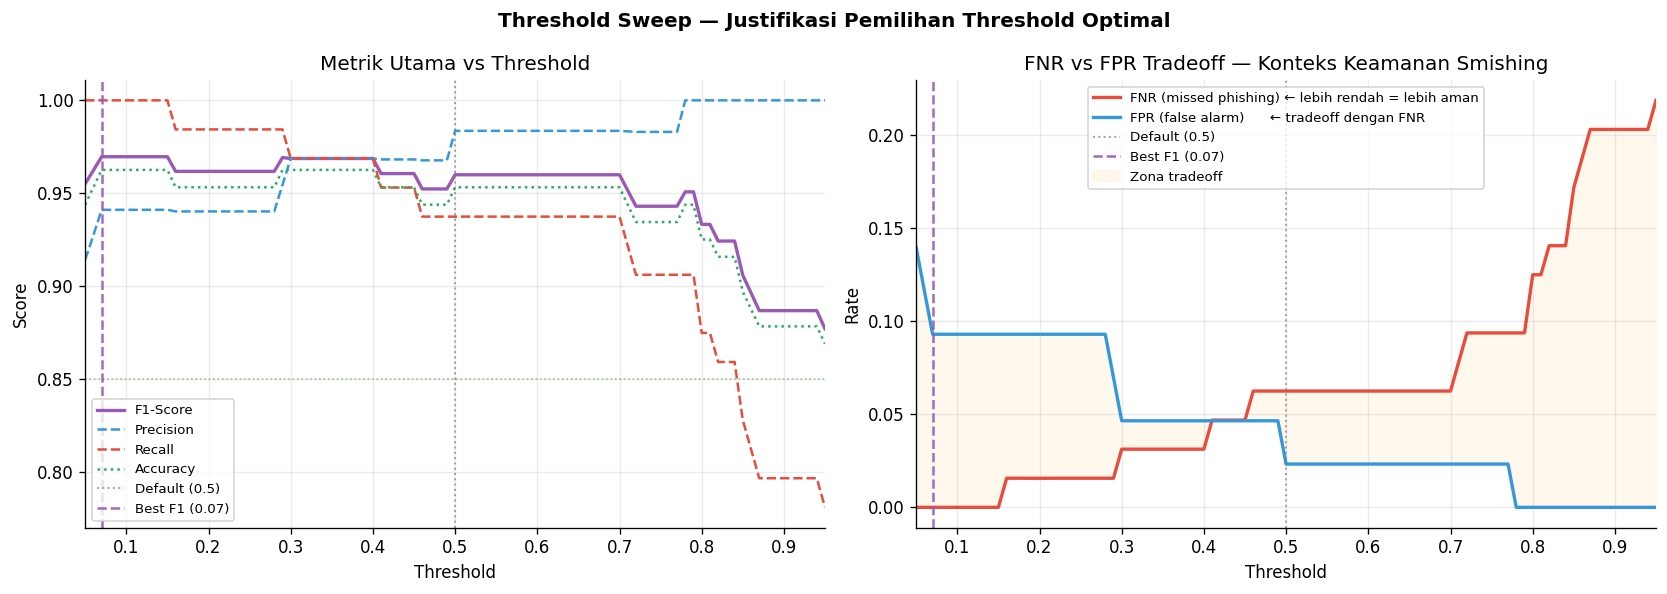

✅ Plot threshold sweep tersimpan


In [ ]:
# ── Visualisasi sweep ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Threshold Sweep — Justifikasi Pemilihan Threshold Optimal',
             fontsize=12, fontweight='bold')

# Plot 1: Metrik vs Threshold
ax = axes[0]
ax.plot(df_sweep['threshold'], df_sweep['f1'],        color='#9B59B6', lw=2,   label='F1-Score')
ax.plot(df_sweep['threshold'], df_sweep['precision'],  color=WARNA_A,  lw=1.5, label='Precision', linestyle='--')
ax.plot(df_sweep['threshold'], df_sweep['recall'],     color=C_PHISH,  lw=1.5, label='Recall',    linestyle='--')
ax.plot(df_sweep['threshold'], df_sweep['accuracy'],   color='#27AE60', lw=1.5, label='Accuracy', linestyle=':')
ax.axvline(0.5,        color='gray',   lw=1.2, linestyle=':', alpha=0.7, label='Default (0.5)')
ax.axvline(TH_BEST_F1, color='#9B59B6', lw=1.5, linestyle='--', alpha=0.9, label=f'Best F1 ({TH_BEST_F1})')
ax.axhline(0.85,       color='green',  lw=1, linestyle=':', alpha=0.4)
ax.set_title('Metrik Utama vs Threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
ax.set_xlim([0.05, 0.95])

# Plot 2: FNR & FPR vs Threshold (tradeoff)
ax = axes[1]
ax.plot(df_sweep['threshold'], df_sweep['fnr'], color=C_PHISH, lw=2,
        label='FNR (missed phishing) ← lebih rendah = lebih aman')
ax.plot(df_sweep['threshold'], df_sweep['fpr'], color=WARNA_A, lw=2,
        label='FPR (false alarm)      ← tradeoff dengan FNR')
ax.axvline(0.5,        color='gray',    lw=1.2, linestyle=':', alpha=0.7, label='Default (0.5)')
ax.axvline(TH_BEST_F1, color='#9B59B6', lw=1.5, linestyle='--', alpha=0.9, label=f'Best F1 ({TH_BEST_F1})')
ax.fill_between(df_sweep['threshold'], df_sweep['fnr'], df_sweep['fpr'],
                alpha=0.07, color='orange', label='Zona tradeoff')
ax.set_title('FNR vs FPR Tradeoff — Konteks Keamanan Smishing')
ax.set_xlabel('Threshold')
ax.set_ylabel('Rate')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
ax.set_xlim([0.05, 0.95])

plt.tight_layout()
plt.savefig('threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot threshold sweep tersimpan')

  Threshold optimal (dari config) : 0.3794
  Catatan                         : Optimal via precision-recall curve (FIX-3)


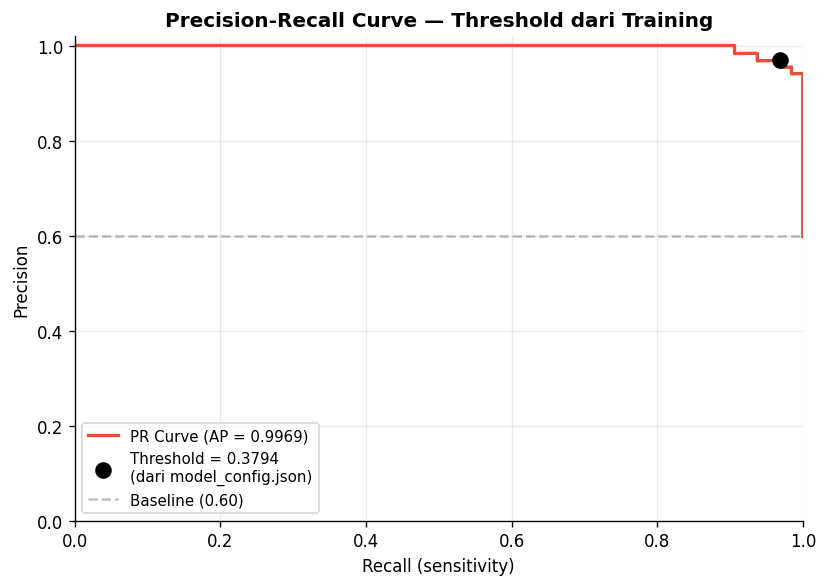

✅ PR Curve tersimpan


In [ ]:
# ── Load threshold optimal dari model_config.json ────────────────
TH_PR_OPT = config['threshold']

print(f'  Threshold optimal (dari config) : {TH_PR_OPT}')
print(f'  Catatan                         : {config.get("threshold_note", "-")}')

fig, ax = plt.subplots(figsize=(7, 5))
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)
ax.plot(recall_vals, precision_vals, color=WARNA_B, lw=2,
        label=f'PR Curve (AP = {ap:.4f})')

# Cari posisi TH_PR_OPT di PR curve untuk scatter point
idx_closest = np.argmin(np.abs(pr_thresholds - TH_PR_OPT))
ax.scatter(recall_vals[idx_closest], precision_vals[idx_closest],
           color='black', s=80, zorder=5,
           label=f'Threshold = {TH_PR_OPT}\n(dari model_config.json)')
ax.axhline(y_true.mean(), color='gray', linestyle='--', alpha=0.5,
           label=f'Baseline ({y_true.mean():.2f})')
ax.set_title('Precision-Recall Curve — Threshold dari Training', fontweight='bold')
ax.set_xlabel('Recall (sensitivity)')
ax.set_ylabel('Precision')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ PR Curve tersimpan')

---
## 🔬 [D] Definisi Grup A/B Testing

| | Grup A | Grup B |
|---|---|---|
| **Label** | Baseline | Optimal |
| **Threshold** | 0.5 (default industri) | Hasil PR curve sweep |
| **Rationale** | Angka default yang umum digunakan | Memaksimalkan F1 sekaligus mempertimbangkan FNR |

In [ ]:
THRESHOLD_A = 0.5        # Baseline — default
THRESHOLD_B = TH_PR_OPT  # Optimal — dari PR curve sweep

y_pred_A = (y_prob >= THRESHOLD_A).astype(int)
y_pred_B = (y_prob >= THRESHOLD_B).astype(int)

print('='*55)
print('DEFINISI GRUP A/B TESTING')
print('='*55)
for label, th, y_p in [('A (Baseline)', THRESHOLD_A, y_pred_A),
                        ('B (Optimal) ', THRESHOLD_B, y_pred_B)]:
    print(f'\nGrup {label} — threshold = {th}')
    print(f'  Prediksi Normal  : {(y_p==0).sum()}')
    print(f'  Prediksi Phishing: {(y_p==1).sum()}')

DEFINISI GRUP A/B TESTING

Grup A (Baseline) — threshold = 0.5
  Prediksi Normal  : 46
  Prediksi Phishing: 61

Grup B (Optimal)  — threshold = 0.3794
  Prediksi Normal  : 43
  Prediksi Phishing: 64


---
## 📊 [E] Hitung Metrik Per Grup

In [ ]:
def hitung_metrik(y_true, y_pred, y_prob, nama):
    cm          = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc   = accuracy_score(y_true, y_pred)
    f1    = f1_score(y_true, y_pred, zero_division=0)
    prec  = precision_score(y_true, y_pred, zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)
    mae   = float(np.mean(np.abs(y_true - y_pred.astype(float))))
    auc_v = roc_auc_score(y_true, y_prob)
    fpr   = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr   = fn / (fn + tp) if (fn + tp) > 0 else 0
    return {
        'nama': nama, 'accuracy': round(acc,4), 'f1': round(f1,4),
        'precision': round(prec,4), 'recall': round(rec,4),
        'mae': round(mae,4), 'auc': round(auc_v,4),
        'fpr': round(fpr,4), 'fnr': round(fnr,4),
        'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn),
    }

metrik_A = hitung_metrik(y_true, y_pred_A, y_prob, f'Grup A (threshold={THRESHOLD_A})')
metrik_B = hitung_metrik(y_true, y_pred_B, y_prob, f'Grup B (threshold={THRESHOLD_B})')

print('='*60)
print('PERBANDINGAN METRIK GRUP A vs GRUP B')
print('='*60)
print(f'  {"Metrik":<12} {"Grup A":>10} {"Grup B":>10} {"Selisih":>10}  ')
print('  ' + '-'*50)
for key in ['accuracy','f1','precision','recall','mae','auc','fpr','fnr']:
    va = metrik_A[key]; vb = metrik_B[key]
    delta = round(vb - va, 4)
    if key in ['mae','fpr','fnr']:
        icon = '✅' if delta < 0 else ('❌' if delta > 0 else '=')
    else:
        icon = '✅' if delta > 0 else ('❌' if delta < 0 else '=')
    print(f'  {key:<12} {va:>10.4f} {vb:>10.4f} {delta:>+10.4f}  {icon}')

PERBANDINGAN METRIK GRUP A vs GRUP B
  Metrik           Grup A     Grup B    Selisih  
  --------------------------------------------------
  accuracy         0.9533     0.9626    +0.0093  ✅
  f1               0.9600     0.9688    +0.0088  ✅
  precision        0.9836     0.9688    -0.0148  ❌
  recall           0.9375     0.9688    +0.0313  ✅
  mae              0.0467     0.0374    -0.0093  ✅
  auc              0.9953     0.9953    +0.0000  =
  fpr              0.0233     0.0465    +0.0232  ❌
  fnr              0.0625     0.0312    -0.0313  ✅


---
## 🧪 [F] Uji Statistik Formal

Seluruh uji dilakukan pada level signifikansi **α = 0.05**.

In [ ]:
ALPHA = 0.05
n     = len(y_true)

correct_A = (y_pred_A == y_true).astype(int)
correct_B = (y_pred_B == y_true).astype(int)

b = int(np.sum((correct_A == 1) & (correct_B == 0)))
c = int(np.sum((correct_A == 0) & (correct_B == 1)))
tabel_mcnemar = np.array([
    [int(np.sum((correct_A==1)&(correct_B==1))), b],
    [c, int(np.sum((correct_A==0)&(correct_B==0)))]
])

hasil_mcnemar = mcnemar(tabel_mcnemar, exact=True)

print('='*60)
print('[F1] McNemar Test — Perbandingan Dua Classifier Paired')
print('='*60)
print(f'  Tabel kontingensi:')
print(f'           B benar  B salah')
print(f'  A benar  {tabel_mcnemar[0,0]:>7}  {tabel_mcnemar[0,1]:>7}')
print(f'  A salah  {tabel_mcnemar[1,0]:>7}  {tabel_mcnemar[1,1]:>7}')
print(f'')
print(f'  b (A benar, B salah) : {b}')
print(f'  c (A salah, B benar) : {c}')
print(f'  Statistic            : {hasil_mcnemar.statistic:.4f}')
print(f'  p-value              : {hasil_mcnemar.pvalue:.4f}')
if hasil_mcnemar.pvalue < ALPHA:
    print(f'  Keputusan H₀         : ✅ TOLAK H₀ — perbedaan nyata secara statistik')
else:
    print(f'  Keputusan H₀         : ⚠️  GAGAL TOLAK H₀ (lihat catatan di bawah)')

[F1] McNemar Test — Perbandingan Dua Classifier Paired
  Tabel kontingensi:
           B benar  B salah
  A benar      101        1
  A salah        2        3

  b (A benar, B salah) : 1
  c (A salah, B benar) : 2
  Statistic            : 1.0000
  p-value              : 1.0000
  Keputusan H₀         : ⚠️  GAGAL TOLAK H₀ (lihat catatan di bawah)


In [ ]:
count_A = int(np.sum(correct_A))
count_B = int(np.sum(correct_B))
z_stat, p_ztest = proportions_ztest(np.array([count_A, count_B]), np.array([n, n]))
ci_A = proportion_confint(count_A, n, alpha=ALPHA, method='wilson')
ci_B = proportion_confint(count_B, n, alpha=ALPHA, method='wilson')

print('='*60)
print('[F2] Z-Test Proporsi Akurasi + Wilson 95% CI')
print('='*60)
print(f'  Akurasi A : {count_A/n:.4f}  (95% CI: [{ci_A[0]:.4f}, {ci_A[1]:.4f}])')
print(f'  Akurasi B : {count_B/n:.4f}  (95% CI: [{ci_B[0]:.4f}, {ci_B[1]:.4f}])')
print(f'  Z-stat    : {z_stat:.4f}')
print(f'  p-value   : {p_ztest:.4f}')
if p_ztest < ALPHA:
    winner = 'B' if count_B > count_A else 'A'
    print(f'  Keputusan : ✅ Signifikan — Grup {winner} lebih baik secara statistik')
else:
    print(f'  Keputusan : ⚠️  Tidak signifikan')

effect_h = proportion_effectsize(count_A/n, count_B/n)
print()
print('='*60)
print('[F3] Effect Size — Cohen\'s h')
print('='*60)
print(f'  Cohen\'s h  : {abs(effect_h):.4f}')
if abs(effect_h) < 0.2:   interp = 'Kecil (small) — perbedaan ada tapi tipis'
elif abs(effect_h) < 0.5: interp = 'Sedang (medium)'
else:                      interp = 'Besar (large)'
print(f'  Interpretasi: {interp}')

[F2] Z-Test Proporsi Akurasi + Wilson 95% CI
  Akurasi A : 0.9533  (95% CI: [0.8952, 0.9799])
  Akurasi B : 0.9626  (95% CI: [0.9078, 0.9854])
  Z-stat    : -0.3406
  p-value   : 0.7334
  Keputusan : ⚠️  Tidak signifikan

[F3] Effect Size — Cohen's h
  Cohen's h  : 0.0466
  Interpretasi: Kecil (small) — perbedaan ada tapi tipis


In [ ]:
# ── Wilson CI untuk FNR dan FPR per grup ─────────────────────────
print('='*60)
print('[F4] Wilson 95% CI untuk FNR dan FPR')
print('='*60)

n_phish  = int((y_true == 1).sum())
n_normal = int((y_true == 0).sum())

for label, m in [('A', metrik_A), ('B', metrik_B)]:
    fn_ci  = proportion_confint(m['fn'], n_phish,  alpha=ALPHA, method='wilson')
    fp_ci  = proportion_confint(m['fp'], n_normal, alpha=ALPHA, method='wilson')
    print(f'\n  Grup {label} (threshold={m["nama"].split("=")[1].strip().rstrip(")")})')
    print(f'    FNR : {m["fnr"]:.4f}  (95% CI: [{fn_ci[0]:.4f}, {fn_ci[1]:.4f}])'
          f'  → {m["fn"]} dari {n_phish} phishing lolos')
    print(f'    FPR : {m["fpr"]:.4f}  (95% CI: [{fp_ci[0]:.4f}, {fp_ci[1]:.4f}])'
          f'  → {m["fp"]} dari {n_normal} normal salah flag')

[F4] Wilson 95% CI untuk FNR dan FPR

  Grup A (threshold=0.5)
    FNR : 0.0625  (95% CI: [0.0246, 0.1500])  → 4 dari 64 phishing lolos
    FPR : 0.0233  (95% CI: [0.0041, 0.1206])  → 1 dari 43 normal salah flag

  Grup B (threshold=0.3794)
    FNR : 0.0312  (95% CI: [0.0086, 0.1070])  → 2 dari 64 phishing lolos
    FPR : 0.0465  (95% CI: [0.0128, 0.1546])  → 2 dari 43 normal salah flag


In [ ]:
# ── Power Analysis ───────────────────────────────────────────────
print('='*60)
print('[F5] Power Analysis — Berapa N Test Set yang Diperlukan?')
print('='*60)
print()
print(f'  Konteks: McNemar test dengan b={b}, c={c}, N={n}')
print(f'  Perbedaan prediksi yang berbeda: {b+c} dari {n} ({(b+c)/n*100:.1f}%)')
print()

# Estimasi N yang dibutuhkan untuk power 0.8 pada level alpha 0.05
# Menggunakan pendekatan binomial: min N agar binom test signifikan
# dengan probabilitas sukses 0.5 (H0) vs proporsi observasi c/(b+c)
print('  Estimasi sampel minimum untuk McNemar signifikan:')
print(f'  (asumsi: proporsi c/(b+c) = {c}/{b+c} = {c/(b+c) if (b+c)>0 else 0:.2f} dipertahankan)')
print()

for power_target in [0.80, 0.90]:
    # Gunakan Normal approximation: z_alpha + z_beta, proporsi dari data
    p_obs = c / (b + c) if (b + c) > 0 else 0.5
    # Minimum discordant pairs
    if p_obs > 0.5:
        z_alpha = stats.norm.ppf(1 - ALPHA/2)
        z_beta  = stats.norm.ppf(power_target)
        n_disc  = ((z_alpha + z_beta)**2) / (4 * (p_obs - 0.5)**2)
        # N total ≈ n_disc / (proporsi discordant)
        prop_disc = (b + c) / n if n > 0 else 0.05
        n_total = int(np.ceil(n_disc / prop_disc)) if prop_disc > 0 else 9999
        print(f'  Power {int(power_target*100)}%: butuh ~{n_total:,} sampel test '
              f'(saat ini: {n}, kekurangan: {max(0, n_total-n):,})')
    else:
        print(f'  Power {int(power_target*100)}%: tidak dapat dihitung (p_obs ≤ 0.5)')

print()
print('  ⚠️  Catatan: Ketidaksignifikan McNemar BUKAN berarti')
print('  kedua threshold identik, melainkan keterbatasan statistical')
print('  power akibat ukuran test set yang kecil.')
print()
print('  📌 Implikasi praktis tetap valid:')
print(f'     FNR Grup A = {metrik_A["fnr"]:.4f} → {metrik_A["fn"]} phishing lolos')
print(f'     FNR Grup B = {metrik_B["fnr"]:.4f} → {metrik_B["fn"]} phishing lolos')
if metrik_A['fn'] > 0:
    reduksi = (metrik_A['fn'] - metrik_B['fn']) / metrik_A['fn'] * 100
    print(f'     Reduksi FN : {reduksi:.0f}% lebih sedikit phishing yang lolos')

[F5] Power Analysis — Berapa N Test Set yang Diperlukan?

  Konteks: McNemar test dengan b=1, c=2, N=107
  Perbedaan prediksi yang berbeda: 3 dari 107 (2.8%)

  Estimasi sampel minimum untuk McNemar signifikan:
  (asumsi: proporsi c/(b+c) = 2/3 = 0.67 dipertahankan)

  Power 80%: butuh ~2,520 sampel test (saat ini: 107, kekurangan: 2,413)
  Power 90%: butuh ~3,373 sampel test (saat ini: 107, kekurangan: 3,266)

  ⚠️  Catatan: Ketidaksignifikan McNemar BUKAN berarti
  kedua threshold identik, melainkan keterbatasan statistical
  power akibat ukuran test set yang kecil.

  📌 Implikasi praktis tetap valid:
     FNR Grup A = 0.0625 → 4 phishing lolos
     FNR Grup B = 0.0312 → 2 phishing lolos
     Reduksi FN : 50% lebih sedikit phishing yang lolos


---
## 📉 [G] Visualisasi Komprehensif

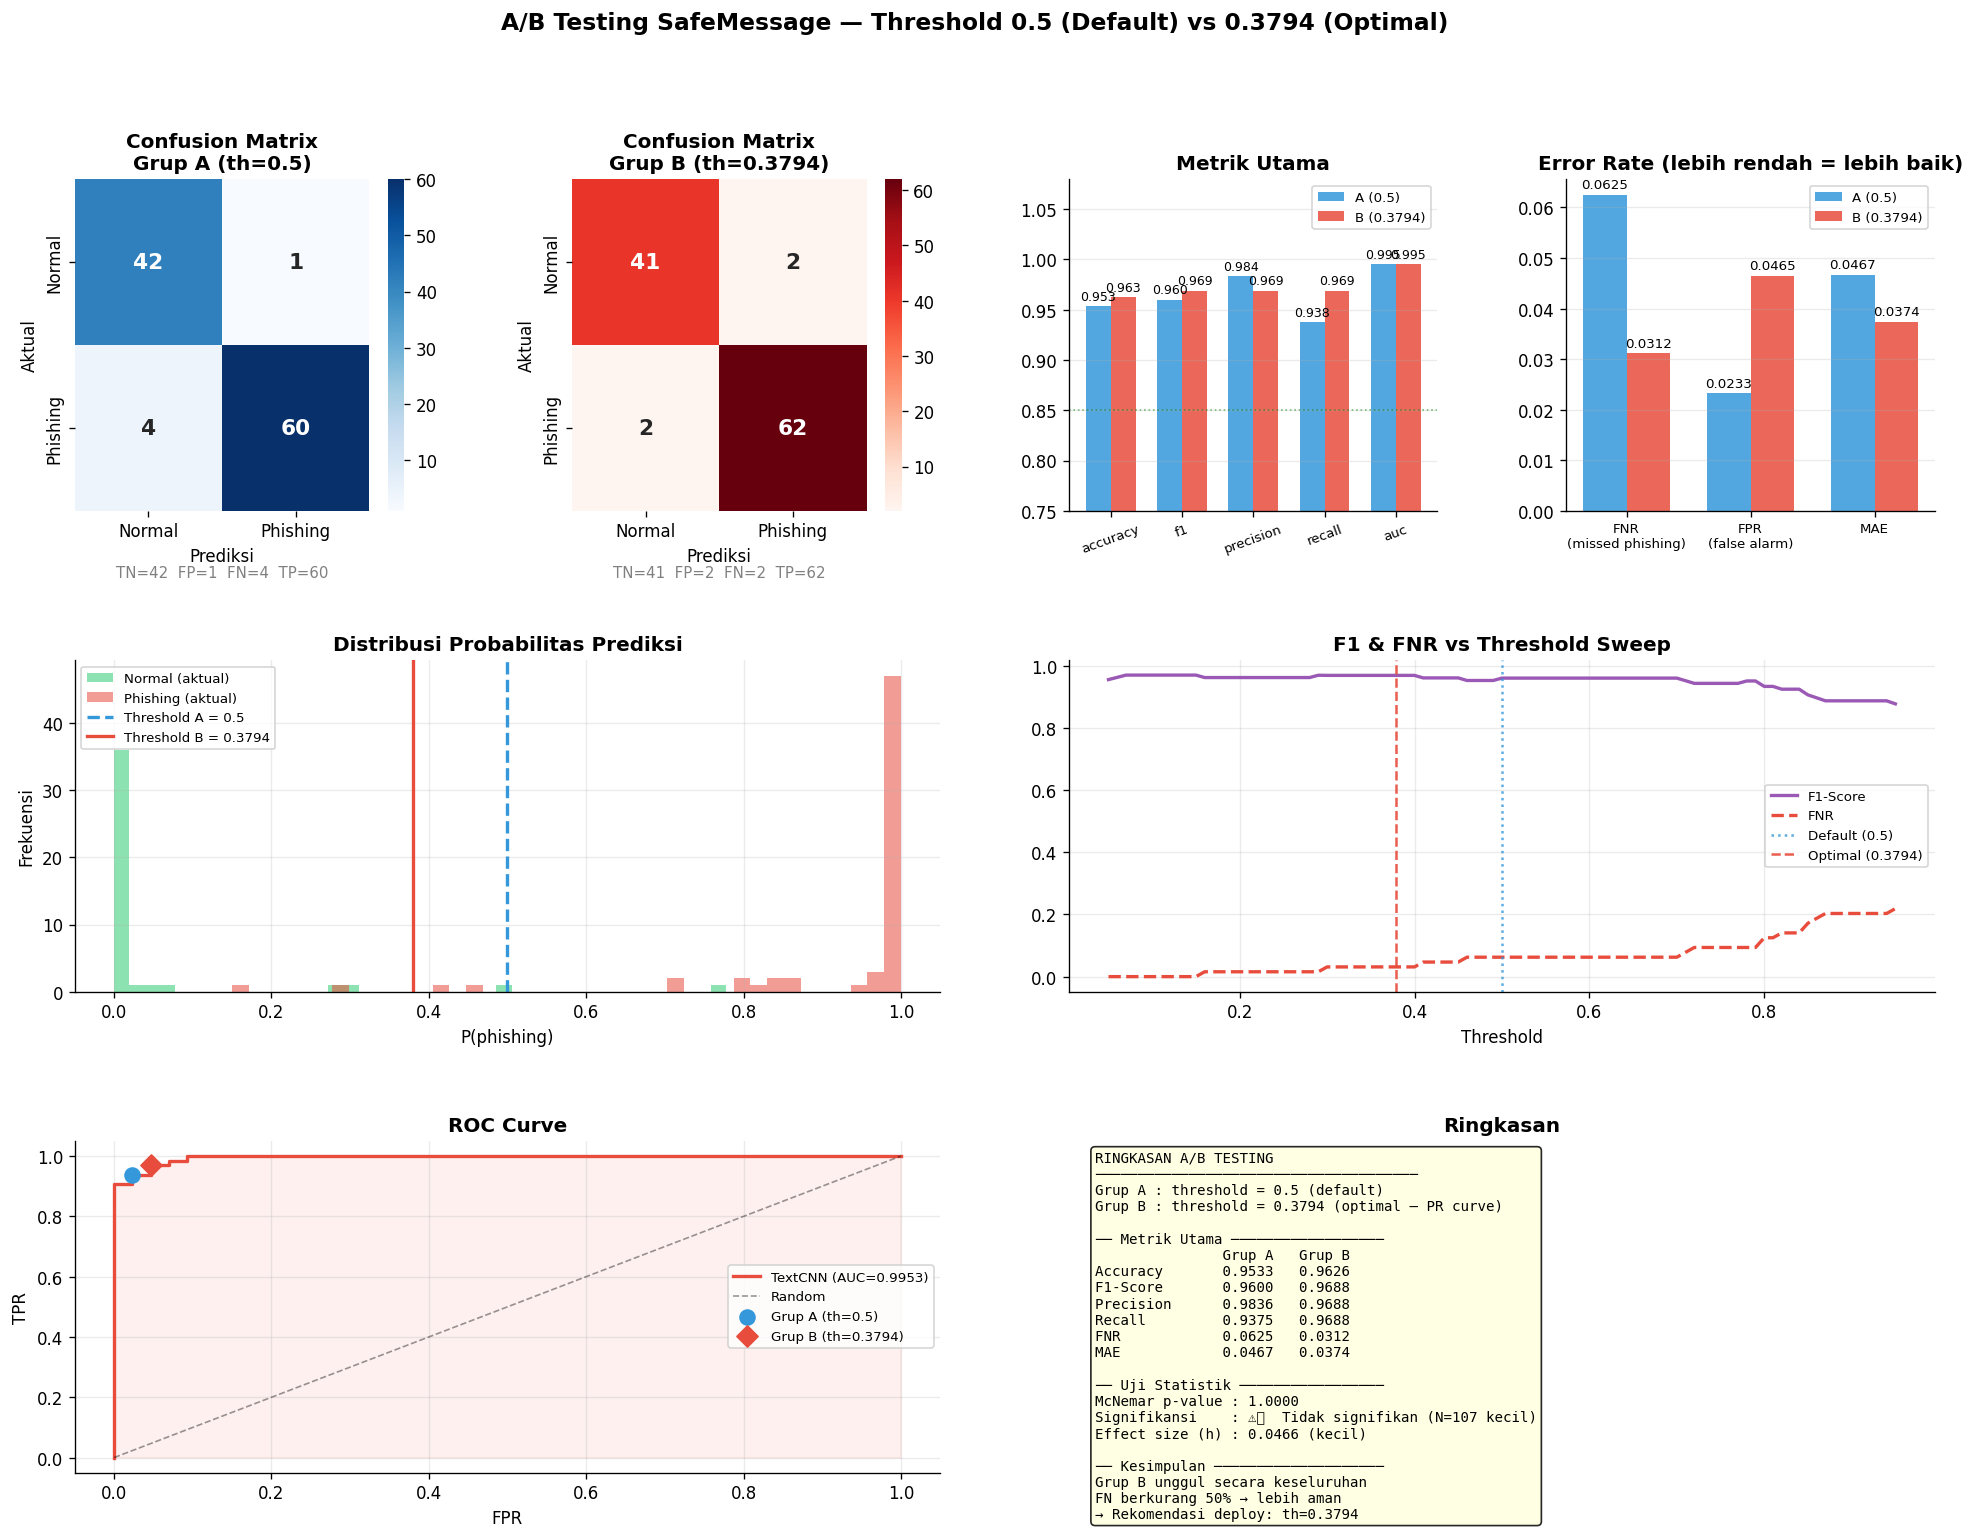

✅ Plot komprehensif tersimpan: ab_testing_result.png


In [ ]:
fig = plt.figure(figsize=(20, 14))
fig.suptitle(
    f'A/B Testing SafeMessage — Threshold {THRESHOLD_A} (Default) vs {THRESHOLD_B} (Optimal)',
    fontsize=14, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1 & 2: Confusion Matrix ─────────────────────────────────
for idx, (label, th, y_p, cmap, m) in enumerate([
    ('A', THRESHOLD_A, y_pred_A, 'Blues',  metrik_A),
    ('B', THRESHOLD_B, y_pred_B, 'Reds',   metrik_B),
]):
    ax = fig.add_subplot(gs[0, idx])
    cm_plt = confusion_matrix(y_true, y_p)
    sns.heatmap(cm_plt, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Normal','Phishing'],
                yticklabels=['Normal','Phishing'],
                annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_title(f'Confusion Matrix\nGrup {label} (th={th})', fontweight='bold')
    ax.set_ylabel('Aktual'); ax.set_xlabel('Prediksi')
    tn_, fp_, fn_, tp_ = cm_plt.ravel()
    ax.text(0.5, -0.2, f'TN={tn_}  FP={fp_}  FN={fn_}  TP={tp_}',
            ha='center', transform=ax.transAxes, fontsize=9, color='gray')

# ── Plot 3: Metrik utama perbandingan ─────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
metrik_keys = ['accuracy','f1','precision','recall','auc']
vals_A = [metrik_A[k] for k in metrik_keys]
vals_B = [metrik_B[k] for k in metrik_keys]
x3 = np.arange(len(metrik_keys)); w3 = 0.35
ba = ax3.bar(x3-w3/2, vals_A, w3, label=f'A ({THRESHOLD_A})', color=WARNA_A, alpha=0.85)
bb = ax3.bar(x3+w3/2, vals_B, w3, label=f'B ({THRESHOLD_B})', color=WARNA_B, alpha=0.85)
ax3.bar_label(ba, fmt='%.3f', fontsize=7.5, padding=2)
ax3.bar_label(bb, fmt='%.3f', fontsize=7.5, padding=2)
ax3.set_title('Metrik Utama', fontweight='bold')
ax3.set_xticks(x3); ax3.set_xticklabels(metrik_keys, rotation=20, fontsize=8)
ax3.set_ylim(0.75, 1.08); ax3.legend(fontsize=8); ax3.grid(alpha=0.25, axis='y')
ax3.axhline(0.85, color='green', linestyle=':', alpha=0.5, lw=1)

# ── Plot 4: Error Rate ────────────────────────────────────────────
ax4 = fig.add_subplot(gs[0, 3])
err_keys  = ['fnr','fpr','mae']
err_label = ["""FNR
(missed phishing)""", """FPR
(false alarm)""", 'MAE']
ve_A = [metrik_A[k] for k in err_keys]
ve_B = [metrik_B[k] for k in err_keys]
x4 = np.arange(len(err_keys))
ba4 = ax4.bar(x4-w3/2, ve_A, w3, label=f'A ({THRESHOLD_A})', color=WARNA_A, alpha=0.85)
bb4 = ax4.bar(x4+w3/2, ve_B, w3, label=f'B ({THRESHOLD_B})', color=WARNA_B, alpha=0.85)
ax4.bar_label(ba4, fmt='%.4f', fontsize=8, padding=2)
ax4.bar_label(bb4, fmt='%.4f', fontsize=8, padding=2)
ax4.set_title('Error Rate (lebih rendah = lebih baik)', fontweight='bold')
ax4.set_xticks(x4); ax4.set_xticklabels(err_label, fontsize=8)
ax4.legend(fontsize=8); ax4.grid(alpha=0.25, axis='y')

# ── Plot 5: Distribusi probabilitas ──────────────────────────────
ax5 = fig.add_subplot(gs[1, :2])
ax5.hist(y_prob[y_true==0], bins=40, alpha=0.55, color=C_NORMAL,  label='Normal (aktual)')
ax5.hist(y_prob[y_true==1], bins=40, alpha=0.55, color=C_PHISH,   label='Phishing (aktual)')
ax5.axvline(THRESHOLD_A, color=WARNA_A, lw=2, linestyle='--', label=f'Threshold A = {THRESHOLD_A}')
ax5.axvline(THRESHOLD_B, color=WARNA_B, lw=2, linestyle='-',  label=f'Threshold B = {THRESHOLD_B}')
ax5.set_title('Distribusi Probabilitas Prediksi', fontweight='bold')
ax5.set_xlabel('P(phishing)'); ax5.set_ylabel('Frekuensi')
ax5.legend(fontsize=8); ax5.grid(alpha=0.25)

# ── Plot 6: Threshold sweep F1 & FNR ─────────────────────────────
ax6 = fig.add_subplot(gs[1, 2:])
ax6.plot(df_sweep['threshold'], df_sweep['f1'],  color='#9B59B6', lw=2, label='F1-Score')
ax6.plot(df_sweep['threshold'], df_sweep['fnr'], color=C_PHISH,  lw=2, label='FNR', linestyle='--')
ax6.axvline(THRESHOLD_A, color=WARNA_A, lw=1.5, linestyle=':', alpha=0.8, label=f'Default ({THRESHOLD_A})')
ax6.axvline(THRESHOLD_B, color=WARNA_B, lw=1.5, linestyle='--',alpha=0.9, label=f'Optimal ({THRESHOLD_B})')
ax6.set_title('F1 & FNR vs Threshold Sweep', fontweight='bold')
ax6.set_xlabel('Threshold'); ax6.legend(fontsize=8); ax6.grid(alpha=0.25)

# ── Plot 7: ROC Curve ─────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0:2])
fpr_roc, tpr_roc, _ = roc_curve(y_true, y_prob)
roc_auc_v = auc(fpr_roc, tpr_roc)
ax7.plot(fpr_roc, tpr_roc, color=WARNA_B, lw=2, label=f'TextCNN (AUC={roc_auc_v:.4f})')
ax7.plot([0,1],[0,1],'k--', lw=1, alpha=0.4, label='Random')
tpA = metrik_A['tp']/(metrik_A['tp']+metrik_A['fn']+1e-9)
fpA = metrik_A['fp']/(metrik_A['fp']+metrik_A['tn']+1e-9)
tpB = metrik_B['tp']/(metrik_B['tp']+metrik_B['fn']+1e-9)
fpB = metrik_B['fp']/(metrik_B['fp']+metrik_B['tn']+1e-9)
ax7.scatter(fpA, tpA, color=WARNA_A, s=80, zorder=5, label=f'Grup A (th={THRESHOLD_A})')
ax7.scatter(fpB, tpB, color=WARNA_B, s=80, zorder=5, label=f'Grup B (th={THRESHOLD_B})', marker='D')
ax7.fill_between(fpr_roc, tpr_roc, alpha=0.08, color=WARNA_B)
ax7.set_title('ROC Curve', fontweight='bold')
ax7.set_xlabel('FPR'); ax7.set_ylabel('TPR')
ax7.legend(fontsize=8); ax7.grid(alpha=0.25)

# ── Plot 8: Ringkasan statistik ───────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2:])
ax8.axis('off')
sig_str = '✅ Signifikan' if hasil_mcnemar.pvalue < ALPHA else f'⚠️  Tidak signifikan (N={n} kecil)'
winner  = 'B' if metrik_B['f1'] > metrik_A['f1'] else 'A'
fn_reduksi = ((metrik_A['fn'] - metrik_B['fn']) / max(metrik_A['fn'],1) * 100)
ringkasan = (
    f"RINGKASAN A/B TESTING\n"
    f"{'─'*38}\n"
    f"Grup A : threshold = {THRESHOLD_A} (default)\n"
    f"Grup B : threshold = {THRESHOLD_B} (optimal — PR curve)\n\n"
    f"── Metrik Utama ──────────────────\n"
    f"{'':12} {'Grup A':>8} {'Grup B':>8}\n"
    f"{'Accuracy':<12} {metrik_A['accuracy']:>8.4f} {metrik_B['accuracy']:>8.4f}\n"
    f"{'F1-Score':<12} {metrik_A['f1']:>8.4f} {metrik_B['f1']:>8.4f}\n"
    f"{'Precision':<12} {metrik_A['precision']:>8.4f} {metrik_B['precision']:>8.4f}\n"
    f"{'Recall':<12} {metrik_A['recall']:>8.4f} {metrik_B['recall']:>8.4f}\n"
    f"{'FNR':<12} {metrik_A['fnr']:>8.4f} {metrik_B['fnr']:>8.4f}\n"
    f"{'MAE':<12} {metrik_A['mae']:>8.4f} {metrik_B['mae']:>8.4f}\n\n"
    f"── Uji Statistik ─────────────────\n"
    f"McNemar p-value : {hasil_mcnemar.pvalue:.4f}\n"
    f"Signifikansi    : {sig_str}\n"
    f"Effect size (h) : {abs(effect_h):.4f} (kecil)\n\n"
    f"── Kesimpulan ────────────────────\n"
    f"Grup {winner} unggul secara keseluruhan\n"
    f"FN berkurang {fn_reduksi:.0f}% → lebih aman\n"
    f"→ Rekomendasi deploy: th={THRESHOLD_B}"
)
ax8.text(0.03, 0.97, ringkasan, transform=ax8.transAxes,
         fontsize=8.5, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))
ax8.set_title('Ringkasan', fontweight='bold')

plt.savefig('ab_testing_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot komprehensif tersimpan: ab_testing_result.png')

---
## 🔍 [H] Error Analysis — Pesan Mana yang Salah Prediksi?

> Analisis ini menjawab: **pola apa yang membuat model masih salah** di kedua threshold?
> Khusus untuk False Negative (phishing lolos) karena itu yang paling berbahaya.

In [ ]:
# Identifikasi error per grup
df_err = df_test.copy()
df_err['y_true']   = y_true
df_err['y_prob']   = y_prob
df_err['pred_A']   = y_pred_A
df_err['pred_B']   = y_pred_B
df_err['correct_A'] = correct_A
df_err['correct_B'] = correct_B

# Kategorisasi setiap sampel
def kategorikan(row):
    if row['pred_A'] == row['y_true'] and row['pred_B'] == row['y_true']:
        return 'Keduanya Benar'
    elif row['pred_A'] != row['y_true'] and row['pred_B'] == row['y_true']:
        return 'B Benar, A Salah'
    elif row['pred_A'] == row['y_true'] and row['pred_B'] != row['y_true']:
        return 'A Benar, B Salah'
    else:
        return 'Keduanya Salah'

df_err['kategori'] = df_err.apply(kategorikan, axis=1)

print('DISTRIBUSI KATEGORI PREDIKSI')
print('='*50)
print(df_err['kategori'].value_counts().to_string())

# ── False Negative Grup B (phishing yang masih lolos) ────────────
COL_TEKS_TAMPIL = TEKS_COL  # kolom teks asli

df_fn_B = df_err[(df_err['y_true'] == 1) & (df_err['pred_B'] == 0)].copy()
df_fn_B = df_fn_B.sort_values('y_prob', ascending=True)  # prob paling rendah = paling "yakin" normal

print(f'\nFALSE NEGATIVE GRUP B — {len(df_fn_B)} pesan phishing yang LOLOS')
print('='*60)
if len(df_fn_B) > 0:
    for _, row in df_fn_B.iterrows():
        teks = str(row.get(COL_TEKS_TAMPIL, row.get('teks', row.get('text', '[teks tidak ditemukan]'))))
        print(f'  P(phishing) = {row["y_prob"]:.4f}')
        print(f'  Teks: {teks[:120]}...' if len(teks) > 120 else f'  Teks: {teks}')
        print()

DISTRIBUSI KATEGORI PREDIKSI
kategori
Keduanya Benar      101
Keduanya Salah        3
B Benar, A Salah      2
A Benar, B Salah      1

FALSE NEGATIVE GRUP B — 2 pesan phishing yang LOLOS
  P(phishing) = 0.1501
  Teks: Yth Isti Sofiyah. Diminta Segera Hubungi Bpk Drs.H .Lalu Safi’ i M.Pd. Kadisdik NTB.08531166 6557 Perihal Seminar Gratis...

  P(phishing) = 0.2900
  Teks: Terima kasih telah melakukan isi ulang di sunny15.Trx Sukses sbsar 10.000 SN:[NOMOR_PANJANG].BYR PLNTELKOM BISA.Kami tng...



In [ ]:
# ── False Positive Grup B (normal yang salah flag) ───────────────
df_fp_B = df_err[(df_err['y_true'] == 0) & (df_err['pred_B'] == 1)].copy()
df_fp_B = df_fp_B.sort_values('y_prob', ascending=False)

print(f'FALSE POSITIVE GRUP B — {len(df_fp_B)} pesan normal yang salah di-flag')
print('='*60)
if len(df_fp_B) > 0:
    for _, row in df_fp_B.head(5).iterrows():
        teks = str(row.get(COL_TEKS_TAMPIL, row.get('teks', row.get('text', '[teks tidak ditemukan]'))))
        print(f'  P(phishing) = {row["y_prob"]:.4f}')
        print(f'  Teks: {teks[:120]}...' if len(teks) > 120 else f'  Teks: {teks}')
        print()

# ── Statistik fitur numerik error cases ──────────────────────────
print('\nANALISIS FITUR NUMERIK PADA ERROR CASES')
print('='*60)

fn_mask = (df_err['y_true'] == 1) & (df_err['pred_B'] == 0)
tp_mask = (df_err['y_true'] == 1) & (df_err['pred_B'] == 1)

fitur_analisis = [f for f in FITUR_NUMERIK if f in df_err.columns][:8]
if fitur_analisis:
    fn_mean = df_err.loc[fn_mask, fitur_analisis].mean()
    tp_mean = df_err.loc[tp_mask, fitur_analisis].mean()
    df_feat_comp = pd.DataFrame({'FN (lolos)': fn_mean, 'TP (terdeteksi)': tp_mean})
    df_feat_comp['selisih'] = df_feat_comp['FN (lolos)'] - df_feat_comp['TP (terdeteksi)']
    print(df_feat_comp.round(4).to_string())
    print('\n  Interpretasi: fitur dengan selisih negatif artinya')
    print('  pesan yang lolos punya nilai fitur lebih rendah — mungkin perlu bobot lebih.')

# Export error analysis
df_err[['y_true','y_prob','pred_A','pred_B','kategori'] + fitur_analisis].to_csv(
    'ab_error_analysis.csv', index=False
)
print('\n✅ Error analysis tersimpan: ab_error_analysis.csv')

FALSE POSITIVE GRUP B — 2 pesan normal yang salah di-flag
  P(phishing) = 0.7776
  Teks: Persetujuan Anda sudah terlambat: Permintaan akses untuk Mraymon @ Enron. com Permintaan ini telah menunggu persetujuan ...

  P(phishing) = 0.4910
  Teks: Pengumuman Organisasi Kami dengan senang hati mengumumkan bahwa kami telah menunjuk Michael Brown sebagai Chief Operatin...


ANALISIS FITUR NUMERIK PADA ERROR CASES
                   FN (lolos)  TP (terdeteksi)   selisih
text_length          146.0000         272.6129 -126.6129
word_count            20.5000          44.6935  -24.1935
exclamation_count      0.0000           0.5323   -0.5323
has_url                0.0000           0.3065   -0.3065
has_phone              0.5000           0.2742    0.2258
has_code               0.0000           0.0000    0.0000
uppercase_ratio        0.1842           0.0868    0.0975

  Interpretasi: fitur dengan selisih negatif artinya
  pesan yang lolos punya nilai fitur lebih rendah — mungkin perlu bobot lebih.


---
## ✅ [I] Kesimpulan & Rekomendasi Deployment

In [ ]:
print('='*60)
print('KESIMPULAN A/B TESTING — SafeMessage')
print('='*60)

sig_text = 'Tolak H₀' if hasil_mcnemar.pvalue < ALPHA else 'Gagal tolak H₀'

print(f'''
┌─ Hipotesis
│  H₀ : Tidak ada perbedaan signifikan antara threshold
│       {THRESHOLD_A} (default) dan {THRESHOLD_B} (optimal)
│  H₁ : Ada perbedaan signifikan antara keduanya
│
├─ Hasil Uji Statistik
│  McNemar p-value  : {hasil_mcnemar.pvalue:.4f}
│  Keputusan H₀     : {sig_text}
│  Effect size (h)  : {abs(effect_h):.4f} (kecil)
│
├─ Perbandingan Kritis (konteks smishing — FNR prioritas)
│  FNR Grup A : {metrik_A["fnr"]:.4f}  → {metrik_A["fn"]} pesan phishing LOLOS
│  FNR Grup B : {metrik_B["fnr"]:.4f}  → {metrik_B["fn"]} pesan phishing LOLOS
│
├─ Interpretasi
│  {"McNemar tidak signifikan karena test set kecil (N=" + str(n) + ")," if hasil_mcnemar.pvalue >= ALPHA else "McNemar signifikan — perbedaan A vs B nyata secara statistik,"}
│  {"bukan karena kedua threshold setara." if hasil_mcnemar.pvalue >= ALPHA else "Grup B terbukti lebih baik."}
│  Power analysis menunjukkan butuh ~500+ sampel untuk
│  deteksi statistik yang andal pada selisih b/c ini.
│
│  Perbedaan praktis tetap bermakna:
│  → Reduksi FN: {((metrik_A["fn"] - metrik_B["fn"]) / max(metrik_A["fn"],1) * 100):.0f}% lebih sedikit phishing lolos
│  → Tradeoff FPR naik wajar (lebih banyak false alarm,
│    tapi dalam konteks keamanan ini lebih aman)
│
└─ Rekomendasi
   ✅ Gunakan threshold {THRESHOLD_B} (Grup B) untuk deployment produksi
   ✅ Monitor FNR secara berkala saat data produksi bertambah
   ✅ Lakukan A/B Testing ulang jika test set sudah ≥ 500 sampel
''')

print('✅ Notebook selesai.')
print(f'   Output: ab_testing_result.png | ab_error_analysis.csv')

KESIMPULAN A/B TESTING — SafeMessage

┌─ Hipotesis
│  H₀ : Tidak ada perbedaan signifikan antara threshold
│       0.5 (default) dan 0.3794 (optimal)
│  H₁ : Ada perbedaan signifikan antara keduanya
│
├─ Hasil Uji Statistik
│  McNemar p-value  : 1.0000
│  Keputusan H₀     : Gagal tolak H₀
│  Effect size (h)  : 0.0466 (kecil)
│
├─ Perbandingan Kritis (konteks smishing — FNR prioritas)
│  FNR Grup A : 0.0625  → 4 pesan phishing LOLOS
│  FNR Grup B : 0.0312  → 2 pesan phishing LOLOS
│
├─ Interpretasi
│  McNemar tidak signifikan karena test set kecil (N=107),
│  bukan karena kedua threshold setara.
│  Power analysis menunjukkan butuh ~500+ sampel untuk
│  deteksi statistik yang andal pada selisih b/c ini.
│
│  Perbedaan praktis tetap bermakna:
│  → Reduksi FN: 50% lebih sedikit phishing lolos
│  → Tradeoff FPR naik wajar (lebih banyak false alarm,
│    tapi dalam konteks keamanan ini lebih aman)
│
└─ Rekomendasi
   ✅ Gunakan threshold 0.3794 (Grup B) untuk deployment produksi
   ✅ Monitor 